In [4]:
import xgi
import numpy as np
import sys
import os
# __file__ is not defined in Jupyter, use current working directory instead
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'edge_rewiring')))
from sod.simpliciality import edit_simpliciality, face_edit_simpliciality, simplicial_fraction

In [3]:
from edge_rewiring import model_generation

H_es = model_generation.model_generation_es(es=0.3, approx_num_C=5000, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=10)
m = H_es.nodes.multi(['degree', 'clustering_coefficient']).asdict()
print(m)
sf = simplicial_fraction(H_es, min_size=2)
es = edit_simpliciality(H_es, min_size=2)
fes = face_edit_simpliciality(H_es, min_size=2)
print(f"Simplicial fraction: {sf}")
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

lst = []
count = 0
for edge in H_es.edges.members():
    # print(H.edges.members())
    if (edge in lst):
        count += 1
    else:
        lst.append(edge)
print(count)


H_sf = model_generation.model_generation_sf(sf=0.3, approx_num_E=1000, num_node=1000, min_size=2, max_size=None)
sf = simplicial_fraction(H_sf, min_size=2)
es = edit_simpliciality(H_sf, min_size=2)
fes = face_edit_simpliciality(H_sf, min_size=2)
print(f"Simplicial fraction: {sf}")
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

lst = []
count = 0
for edge in H_sf.edges.members():
    # print(H.edges.members())
    if (edge in lst):
        count += 1
    else:
        lst.append(edge)
print(count)

# Show testing method is effective
# H1 = xgi.Hypergraph()
# nodes = [i for i in range(10)]
# H1.add_nodes_from(nodes)
# H1.add_edge({1, 9})
# H1.add_edge({1, 9})
# lst = []
# count = 0
# for edge in H1.edges.members():
#     print(H1.edges.members())
#     if (edge in lst):
#         count += 1
#     else:
#         lst.append(edge)
# print(count)

C_distribution: [154 735 422 638 399 606 662 579 475 330]
{0: {'degree': 0, 'clustering_coefficient': 0.0}, 1: {'degree': 0, 'clustering_coefficient': 0.0}, 2: {'degree': 0, 'clustering_coefficient': 0.0}, 3: {'degree': 72, 'clustering_coefficient': 1.0}, 4: {'degree': 0, 'clustering_coefficient': 0.0}, 5: {'degree': 0, 'clustering_coefficient': 0.0}, 6: {'degree': 0, 'clustering_coefficient': 0.0}, 7: {'degree': 0, 'clustering_coefficient': 0.0}, 8: {'degree': 0, 'clustering_coefficient': 0.0}, 9: {'degree': 0, 'clustering_coefficient': 0.0}, 10: {'degree': 0, 'clustering_coefficient': 0.0}, 11: {'degree': 0, 'clustering_coefficient': 0.0}, 12: {'degree': 0, 'clustering_coefficient': 0.0}, 13: {'degree': 0, 'clustering_coefficient': 0.0}, 14: {'degree': 0, 'clustering_coefficient': 0.0}, 15: {'degree': 0, 'clustering_coefficient': 0.0}, 16: {'degree': 0, 'clustering_coefficient': 0.0}, 17: {'degree': 0, 'clustering_coefficient': 0.0}, 18: {'degree': 0, 'clustering_coefficient': 0.0}, 

In [ ]:
# Note the cmultiedge related methods in xgi are really confusing/weird. Try avoid using it.
# Below is an example of multiedge method not working
H = xgi.Hypergraph()
nodes = [i for i in range(10)]
H.add_nodes_from(nodes)
H.add_edge({1, 10})
H.add_edge({2, 10})
H.add_edge({4,8})
H.add_edge({1, 2, 10})
m = H.nodes.multi(['degree', 'clustering_coefficient'])
print(m.asdict())
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(multiedges=True)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(singletons=True)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

{0: {'degree': 0, 'clustering_coefficient': 0.0}, 1: {'degree': 2, 'clustering_coefficient': 1.0}, 2: {'degree': 2, 'clustering_coefficient': 1.0}, 3: {'degree': 0, 'clustering_coefficient': 0.0}, 4: {'degree': 1, 'clustering_coefficient': 0.0}, 5: {'degree': 0, 'clustering_coefficient': 0.0}, 6: {'degree': 0, 'clustering_coefficient': 0.0}, 7: {'degree': 0, 'clustering_coefficient': 0.0}, 8: {'degree': 1, 'clustering_coefficient': 0.0}, 9: {'degree': 0, 'clustering_coefficient': 0.0}, 10: {'degree': 3, 'clustering_coefficient': 1.0}}
Edit simpliciality: 0.8
Face edit simpliciality: 0.6666666666666666
Edit simpliciality: 0.75
Face edit simpliciality: 0.6666666666666666
Edit simpliciality: 0.75
Face edit simpliciality: 0.6666666666666666


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,8) # make figures big for easier viewing 
                                        #    (width, height in inches)
# Experiment to find the relationship between edit simpliciality and face edit simpliciality
# for a range of edit simpliciality values
es = []
fes = []
float_range = np.arange(0, 1, 0.02)
for i in range(len(float_range)):
	H = model_generation.edge_rewire_model(edit_simpliciality=float_range[i], approx_num_C=5000, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
	es.append(edit_simpliciality(H, min_size=2))
	fes.append(face_edit_simpliciality(H, min_size=2))
fig, ax = plt.subplots()
ax.plot(es, fes, color='red')

### DO THIS: Add the line of code to plot the trajectory here

ax.set_xlabel('es')
ax.set_ylabel('fes')
# An example of implicit line continuation. Python knows to keep on reading to
#    the next line because the set of parentheses hasn't been closed by the end
#    of the first line.
ax.set_title("velocity vs mass".
             format(es, fes))
plt.show()


selected_edge_idx: 1
Adding edge: [(454, 595), (454, 767), (454, 417), (595, 767), (595, 417), (767, 417), (454, 595, 767), (454, 595, 417), (454, 767, 417), (595, 767, 417), (454, 595, 767, 417)]
selected_edge_idx: 0
Adding edge: [(454, 595), (454, 767), (454, 417), (595, 767), (595, 417), (767, 417), (454, 595, 767), (454, 595, 417), (454, 767, 417), (595, 767, 417), (454, 595, 767, 417)]
selected_edge_idx: 6
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 1546), (109, 1868, 1546), (1421, 109, 1868, 1546)]
selected_edge_idx: 10
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 1546), (109, 1868, 1546), (1421, 109, 1868, 1546)]
selected_edge_idx: 4
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 15

XGIError: Every node must be a member of an edge to avoid divide by zero error!

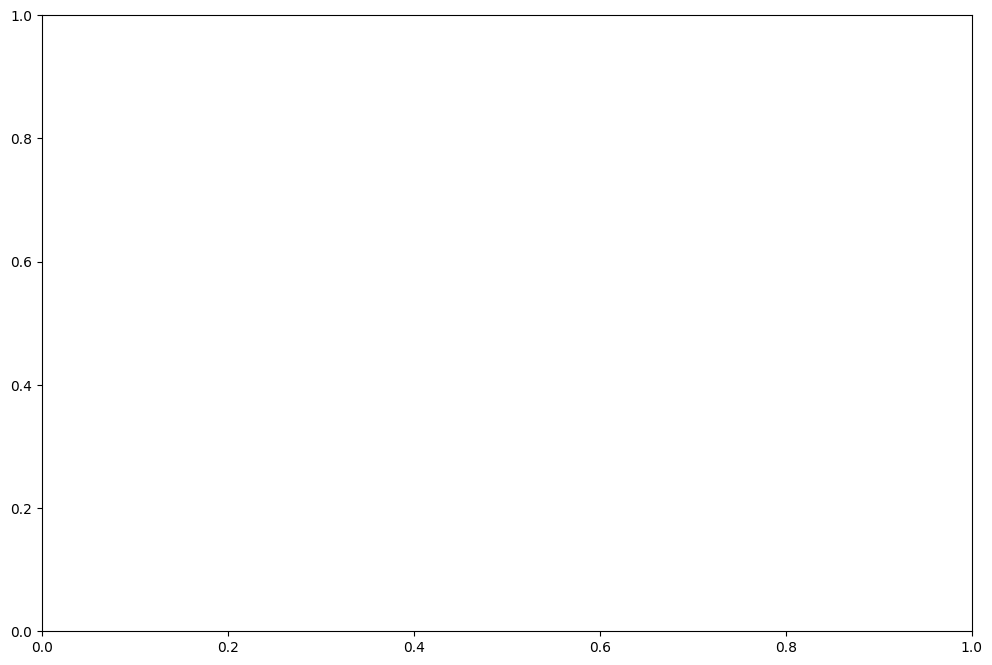

In [ ]:
node = []
cc = []
# Experiment to find the relationship between edit simpliciality and clustering coefficient
fig, ax = plt.subplots()
for i in range(10):
    H = model_generation.edge_rewire_model(0.5, approx_num_C=50, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
    community_clustering = xgi.spectral_clustering(H)
    print(community_clustering)
# 	for idx in range(len(clustering_coefficient)):
# 		node.append(idx)
# 		cc.append(clustering_coefficient[idx])
# ax.scatter(node, cc, color='red')
     



# ### DO THIS: Add the line of code to plot the trajectory here

# ax.set_xlabel('node')
# ax.set_ylabel('cc')
# # An example of implicit line continuation. Python knows to keep on reading to
# #    the next line because the set of parentheses hasn't been closed by the end
# #    of the first line.
# ax.set_title("node vs cc".
#              format(node, cc))
# plt.show()

Testing approx_num_C = 3840
C_distribution: [21 19 20 21 26 24 19 10 31 24 20 15 37 27 15  2 42 20 22 15 13 36  3 25
 17  3 21 32 36 21 23 14 17 29  4  9 31 16 20 26  6 26 22  2 15 31 28 23
  7 21 21 19 38 20  7 17  7 13 25  6 24  4 10 19 19  4 15 18 22 24 17  9
 16 27 30 17 30  7  4  4 14 37  4 20 30  8 17 20 22 33 21 36 22 22 32 27
 10 16 22 17  6 12 19 12 22  7 30 26 46 17 14  3 11 19 11  5 15 25 22 12
 31 18 15 17 22 23 19 22 11 24 18 36  5 15 22 23 13 32 25 27 25  8 23 11
 22 13 16 19 19 20 11 24 17 30  8 13 36 14 32 20 10  1 27 28 21 29 13 19
 24 16 18  7 21 22 16 13 17 17 26 17 28 18 25 11 22 27 25 18 21 31 16  8
 20 16 28 22 27 18 23 11]
Edit simpliciality for C=3840: 0.9000175716042875
Testing approx_num_C = 3850
C_distribution: [ 6 23 30 23 13  6 20 13 31 23 24 15  2 31 30  7 29 22 22 17 23 30 31 24
 25 11  7 29 10 24  3 20 24 15 12 29 22 20 31 21 19 19 10  2 17 26 28  5
 10 21 29  7 25  3 17 34 23 16  2  2 32 13 15 21 47 38 16 14 34  8 12 30
 19 14  8 19 31 12  1  5 11 13 16

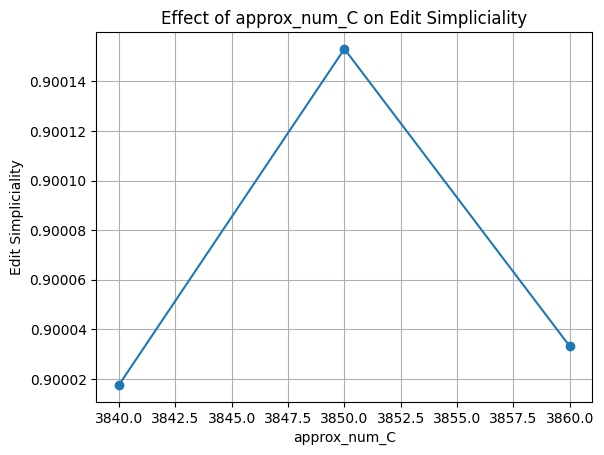

In [11]:
from edge_rewiring import model_generation
from sod.simpliciality import edit_simpliciality
import matplotlib.pyplot as plt

# Fixed parameters
es = 0.9
num_max_hyperedge = 200
num_node = 2000
min_size = 2
max_size = None

# Range of approx_num_C values to test
C_values = [3840, 3850, 3860]

results = []

for C in C_values:
    print(f"Testing approx_num_C = {C}")
    H = model_generation.model_generation_es(
        es=es,
        approx_num_C=C,
        num_max_hyperedge=num_max_hyperedge,
        num_node=num_node,
        min_size=min_size,
        max_size=max_size
    )

    curr_es = edit_simpliciality(H, min_size=2)
    print(f"Edit simpliciality for C={C}: {curr_es}")
    results.append((C, curr_es))

# Plot results
C_vals, es_vals = zip(*results)
plt.plot(C_vals, es_vals, marker='o')
plt.xlabel("approx_num_C")
plt.ylabel("Edit Simpliciality")
plt.title("Effect of approx_num_C on Edit Simpliciality")
plt.grid(True)
plt.show()
